# Занятие 2. Кластеризация HR-данных: поиск типов кандидатов и вакансий

## Зачем нужен этот ноутбук

В этом ноутбуке мы показываем, как подключить **AI-инструменты для аналитики данных** к трём открытым HR-датасетам.

Здесь мы работаем с реальными данными, где у каждого кандидата есть:

- оценки соответствия вакансии (macro_scores_avg, micro_scores_avg);
- список навыков;
- текстовое обоснование.

Главная цель занятия:

- загрузить **три реальных HR-датасета** из интернета;
- подготовить данные для модели;
- применить **кластеризацию** для поиска типов кандидатов и вакансий;
- объяснить результат на языке аналитика данных.

## Важный методический смысл

В дипломном проекте студенту недостаточно просто написать код. Нужно уметь пройти полный путь:

1. найти открытые датасеты по теме проекта;
2. загрузить их;
3. понять структуру и очистить данные;
4. применить AI-метод;
5. сделать выводы и объяснить, зачем они нужны.

Этот ноутбук показывает именно такой путь для трёх HR-датасетов.

## Практическая ячейка 1. Импорт библиотек

### Что делает эта ячейка
- подключает библиотеки для анализа данных, графиков и AI;
- импортирует классы для кластеризации, масштабирования, оценки качества и снижения размерности.

### Какие библиотеки мы используем

**`pandas`**  
Главная библиотека для работы с таблицами в Python.  
Позволяет загружать CSV, фильтровать строки, переименовывать столбцы, считать статистику и группировать данные.

**`matplotlib.pyplot`**  
Библиотека для построения графиков.  
С её помощью мы покажем результаты анализа и AI-модели.

**`StandardScaler` из `sklearn.preprocessing`**  
Масштабирует признаки: приводит их к сопоставимому масштабу.  
Это полезно перед AI-алгоритмами, чтобы один признак не доминировал над другим.

**`KMeans` из `sklearn.cluster`**  
Алгоритм кластеризации.  
Он делит объекты на группы так, чтобы похожие объекты оказывались в одном кластере.

**`silhouette_score` из `sklearn.metrics`**  
Метрика качества кластеризации.  
Помогает понять, насколько удачно модель разделила данные на группы.

**`PCA` из `sklearn.decomposition`**  
Метод уменьшения размерности.  
Позволяет показать многомерные данные на двумерном графике.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


## Практическая ячейка 2. Загрузка HR-датасетов

### Что делает эта ячейка
- загружает три датасета из локальных файлов;
- создаёт дополнительные признаки (количество навыков) для каждого датасета;
- выводит размеры таблиц для проверки.

### Почему важна подготовка признаков
Кластеризация работает с числами. Поле `skills` хранит текст, поэтому мы преобразуем его в число — количество навыков. Это простой, но эффективный признак для группировки кандидатов.

In [15]:
# Пути к файлам (относительно папки notebooks)
hf_path = "../data/huggingface/resume_scores_clean.csv"
kaggle_path = "../data/kaggle_resume/resume_data.csv"
hh_path = "../data/hhru/it.csv"

# Загрузка
df_hf = pd.read_csv(hf_path)
df_kaggle = pd.read_csv(kaggle_path)
df_hh = pd.read_csv(hh_path, sep=';')

print("✅ Hugging Face (оценки кандидатов):", df_hf.shape)
print("✅ Resume Dataset (структурированные резюме):", df_kaggle.shape)
print("✅ hh.ru (русскоязычные вакансии):", df_hh.shape)

# Создаём дополнительные признаки для всех датасетов
df_hf['skills_count'] = df_hf['skills'].fillna('').apply(lambda x: len(str(x).split(',')) if x else 0)

if 'skills' in df_kaggle.columns:
    df_kaggle['skills_count'] = df_kaggle['skills'].fillna('').apply(lambda x: len(str(x).split(',')) if x else 0)
else:
    df_kaggle['skills_count'] = 0

if 'hard_skills' in df_hh.columns:
    df_hh['skills_count'] = df_hh['hard_skills'].fillna('').apply(lambda x: len(str(x).split(',')) if x else 0)
else:
    df_hh['skills_count'] = 0

print("\n✅ Признаки подготовлены")

✅ Hugging Face (оценки кандидатов): (854, 6)
✅ Resume Dataset (структурированные резюме): (9544, 35)
✅ hh.ru (русскоязычные вакансии): (171140, 31)

✅ Признаки подготовлены


## Практическая ячейка 3. Кластеризация кандидатов (Hugging Face)

### Что делает эта ячейка
- выбирает признаки для кластеризации: макро-оценка, микро-оценка, количество навыков;
- удаляет строки с пропусками;
- масштабирует признаки через `StandardScaler`.

### Почему важно масштабирование
Признаки имеют разные масштабы:
- `macro_scores_avg` и `micro_scores_avg` — от 1 до 10;
- `skills_count` — от 0 до 20.

Без масштабирования алгоритм кластеризации будет сильнее ориентироваться на признак с большими числами. `StandardScaler` приводит все признаки к единому масштабу (среднее = 0, стандартное отклонение = 1).

In [16]:
print("="*60)
print("ЧАСТЬ 1. КЛАСТЕРИЗАЦИЯ КАНДИДАТОВ (Hugging Face)")
print("="*60)

# Признаки для кластеризации
feature_cols = ['macro_scores_avg', 'micro_scores_avg', 'skills_count']

# Удаляем пропуски
df_hf_clean = df_hf[feature_cols].dropna().copy()
print(f"Количество образцов: {len(df_hf_clean)}")

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_hf_clean[feature_cols])

print("\nПервые 5 строк после масштабирования:")
display(pd.DataFrame(X_scaled, columns=feature_cols).head().round(3))

ЧАСТЬ 1. КЛАСТЕРИЗАЦИЯ КАНДИДАТОВ (Hugging Face)
Количество образцов: 854

Первые 5 строк после масштабирования:


,macro_scores_avg,micro_scores_avg,skills_count
0,1.670,2.039,0.460
1,0.607,0.669,-2.226
2,1.670,1.623,-2.226
3,0.054,1.254,0.460
4,-1.296,0.212,0.460


## Практическая ячейка 4. Подбор количества кластеров: первый AI-анализ

### Что делает эта ячейка
- обучает несколько моделей `KMeans` с разным количеством кластеров;
- считает метрику `silhouette_score` для каждой;
- помогает выбрать разумное значение `k`.

### Что такое `KMeans`
`KMeans` — это алгоритм **кластеризации**, то есть обучения **без учителя**.  
Это значит:
- у нас нет готовых правильных ответов;
- модель не знает заранее, кто к какой группе относится;
- она сама ищет похожие объекты и делит их на кластеры.

### Что такое `silhouette_score`
Метрика качества кластеризации.  
Оценка лежит от -1 до 1:
- ближе к 1 — кластеры хорошие;
- около 0 — кластеры слабо разделены;
- меньше 0 — плохое разделение.

In [17]:
model_selection_results = []

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = model.fit_predict(X_scaled)
    
    model_selection_results.append({
        "k": k,
        "silhouette_score": round(silhouette_score(X_scaled, labels), 4)
    })

selection_df = pd.DataFrame(model_selection_results)
print("\nSilhouette scores:")
display(selection_df)

best_k = selection_df.loc[selection_df['silhouette_score'].idxmax(), 'k']
final_k = 3 if best_k == 2 else 4
print(f"\nВыбрано {final_k} кластеров")


Silhouette scores:


,k,silhouette_score
0,2,0.3725
1,3,0.4094
2,4,0.3378
3,5,0.2993
4,6,0.2883



Выбрано 4 кластеров


## Практическая ячейка 5. Обучение AI-модели кластеризации и построение профиля кластеров

### Что делает эта ячейка
- обучает итоговую модель `KMeans` с выбранным количеством кластеров;
- присваивает каждому кандидату номер кластера;
- считает размеры кластеров;
- строит усреднённый профиль каждой группы.

### Что означают центры кластеров
У KMeans у каждого кластера есть **центр**.  
Это как "средний профиль" группы.

Если кластер имеет высокую среднюю макро-оценку и много навыков, мы можем интерпретировать его как группу "сильных кандидатов".

### Что делает `groupby().mean()`
После кластеризации нам мало просто получить номера групп.  
Нужно понять, **чем кластеры отличаются**.

Для этого мы:
1. группируем данные по номеру кластера;
2. считаем средние значения признаков внутри каждой группы.

In [18]:
# Обучение модели
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init='auto')
df_hf_clean['cluster'] = kmeans.fit_predict(X_scaled)

# Профили кластеров
cluster_profile = df_hf_clean.groupby('cluster')[feature_cols].mean().round(3)
print("\nПрофили кластеров:")
display(cluster_profile)

# Интерпретация
print("\nТекстовая интерпретация:")
for cluster_id in sorted(cluster_profile.index):
    profile = cluster_profile.loc[cluster_id]
    desc = []
    if profile['macro_scores_avg'] > 3.5:
        desc.append("высокая макро-оценка")
    elif profile['macro_scores_avg'] < 2.5:
        desc.append("низкая макро-оценка")
    else:
        desc.append("средняя макро-оценка")
    
    if profile['micro_scores_avg'] > 3.5:
        desc.append("высокая микро-оценка")
    elif profile['micro_scores_avg'] < 2.5:
        desc.append("низкая микро-оценка")
    else:
        desc.append("средняя микро-оценка")
    
    if profile['skills_count'] > 5:
        desc.append("много навыков")
    elif profile['skills_count'] < 2:
        desc.append("мало навыков")
    
    print(f"Кластер {cluster_id}: {', '.join(desc)}")


Профили кластеров:


,macro_scores_avg,micro_scores_avg,skills_count
cluster,,,
0,6.222,4.696,2.293
1,7.552,6.932,4.992
2,3.320,1.897,4.603
3,5.938,4.150,4.906



Текстовая интерпретация:
Кластер 0: высокая макро-оценка, высокая микро-оценка
Кластер 1: высокая макро-оценка, высокая микро-оценка
Кластер 2: средняя макро-оценка, низкая микро-оценка
Кластер 3: высокая макро-оценка, высокая микро-оценка


## Практическая ячейка 6. Визуализация AI-результатов: PCA и scatter plot

### Что делает эта ячейка
- уменьшает размерность данных с 3 признаков до 2 компонент;
- строит scatter plot кластеров;
- показывает распределение кандидатов на плоскости.

### Зачем нужен `PCA`
У нас 3 признака. Показать 3-мерное пространство на обычном графике сложно.  
Поэтому мы применяем **PCA** — метод уменьшения размерности.

### Что такое `explained_variance_ratio_`
Показывает, какую долю информации объясняет каждая главная компонента.  
Это помогает понять, насколько честно 2D-график отражает исходные данные.

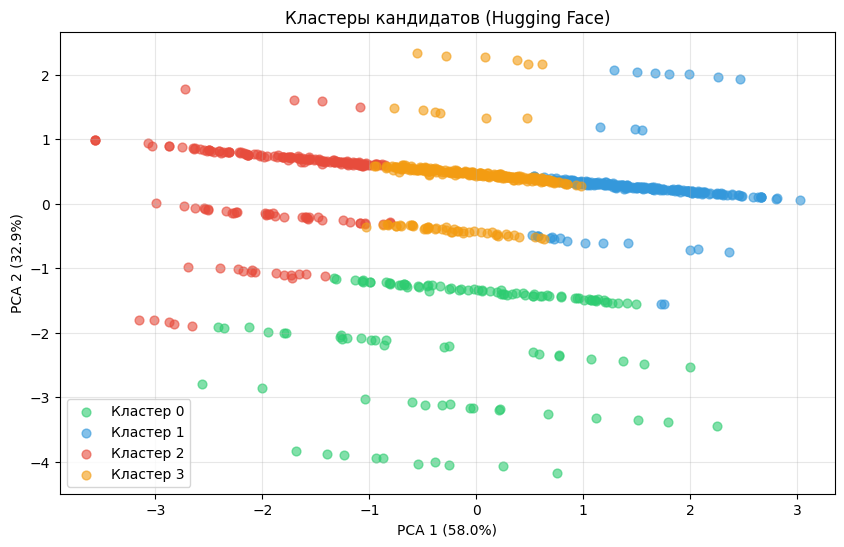

In [19]:
# PCA для визуализации
pca = PCA(n_components=2, random_state=42)
pca_coordinates = pca.fit_transform(X_scaled)

df_hf_clean['pca1'] = pca_coordinates[:, 0]
df_hf_clean['pca2'] = pca_coordinates[:, 1]

plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for i, cluster_id in enumerate(sorted(df_hf_clean['cluster'].unique())):
    cluster_data = df_hf_clean[df_hf_clean['cluster'] == cluster_id]
    plt.scatter(cluster_data['pca1'], cluster_data['pca2'], 
                s=40, alpha=0.6, c=colors[i % len(colors)], label=f'Кластер {cluster_id}')

plt.title("Кластеры кандидатов (Hugging Face)")
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Практическая ячейка 7. Кластеризация резюме (Resume Dataset)

### Что делает эта ячейка
- определяет доступные текстовые поля (образование, опыт, навыки);
- преобразует текст в числовые признаки (длина текста);
- выполняет кластеризацию на основе этих признаков.

### Почему длина текста
Длина текста — простой, но информативный признак.  
Резюме разного объёма могут принадлежать к разным группам (например, краткие vs подробные).

In [20]:
print("="*60)
print("ЧАСТЬ 2. КЛАСТЕРИЗАЦИЯ РЕЗЮМЕ (Kaggle)")
print("="*60)

# Определяем доступные признаки
available_cols = []
if 'education' in df_kaggle.columns:
    available_cols.append('education')
if 'work_experience' in df_kaggle.columns:
    available_cols.append('work_experience')
if 'skills' in df_kaggle.columns:
    available_cols.append('skills')
if 'skills_count' in df_kaggle.columns:
    available_cols.append('skills_count')

print(f"Доступные текстовые поля: {available_cols}")

# Создаём числовые признаки из текстовых полей
for col in available_cols:
    if col != 'skills_count':
        df_kaggle[f'{col}_length'] = df_kaggle[col].fillna('').astype(str).str.len()

# Выбираем числовые признаки
numeric_cols = [col for col in df_kaggle.columns if col.endswith('_length') or col == 'skills_count']
if numeric_cols:
    print(f"\nЧисловые признаки для кластеризации: {numeric_cols}")
    
    df_kaggle_clean = df_kaggle[numeric_cols].dropna().copy()
    
    if len(df_kaggle_clean) > 10:
        scaler2 = StandardScaler()
        X_scaled2 = scaler2.fit_transform(df_kaggle_clean)
        
        kmeans2 = KMeans(n_clusters=3, random_state=42, n_init='auto')
        df_kaggle_clean['cluster'] = kmeans2.fit_predict(X_scaled2)
        
        print("\nРазмеры кластеров:")
        print(df_kaggle_clean['cluster'].value_counts().sort_index())
    else:
        print("Недостаточно данных для кластеризации")
else:
    print("Нет числовых признаков для кластеризации")

ЧАСТЬ 2. КЛАСТЕРИЗАЦИЯ РЕЗЮМЕ (Kaggle)
Доступные текстовые поля: ['skills', 'skills_count']

Числовые признаки для кластеризации: ['skills_count', 'skills_length']

Размеры кластеров:
cluster
0    6744
1    2604
2     196
Name: count, dtype: int64


## Практическая ячейка 8. Кластеризация вакансий (hh.ru)

### Что делает эта ячейка
- создаёт признаки: нормализованная зарплата и опыт в годах;
- выполняет кластеризацию вакансий на основе этих признаков.

### Зачем это нужно
Вакансии можно сегментировать по уровню зарплаты и требуемому опыту.  
Это помогает понять структуру рынка труда и выделить типовые группы вакансий.

In [21]:
print("="*60)
print("ЧАСТЬ 3. КЛАСТЕРИЗАЦИЯ ВАКАНСИЙ (hh.ru)")
print("="*60)

hh_features = []

if 'salary_from' in df_hh.columns:
    df_hh['salary_normalized'] = df_hh['salary_from'].fillna(0) / 100000
    hh_features.append('salary_normalized')

if 'experience' in df_hh.columns:
    exp_map = {'0-1': 0.5, '1-3': 2, '3-6': 4.5, 'более 6': 7}
    df_hh['experience_years'] = df_hh['experience'].map(exp_map).fillna(0)
    hh_features.append('experience_years')

print(f"Признаки для кластеризации вакансий: {hh_features}")

if hh_features:
    df_hh_clean = df_hh[hh_features].dropna().copy()
    print(f"\nКоличество образцов для анализа: {len(df_hh_clean)}")
    
    scaler3 = StandardScaler()
    X_hh_scaled = scaler3.fit_transform(df_hh_clean)
    
    kmeans_hh = KMeans(n_clusters=3, random_state=42, n_init='auto')
    df_hh_clean['cluster'] = kmeans_hh.fit_predict(X_hh_scaled)
    
    print("\nРазмеры кластеров вакансий:")
    print(df_hh_clean['cluster'].value_counts().sort_index())
    
    print("\nПрофили кластеров вакансий:")
    display(df_hh_clean.groupby('cluster')[hh_features].mean().round(3))
else:
    print("Нет признаков для кластеризации вакансий")

ЧАСТЬ 3. КЛАСТЕРИЗАЦИЯ ВАКАНСИЙ (hh.ru)
Признаки для кластеризации вакансий: ['salary_normalized', 'experience_years']

Количество образцов для анализа: 171140

Размеры кластеров вакансий:
cluster
0    101606
1       905
2     68629
Name: count, dtype: int64

Профили кластеров вакансий:


,salary_normalized,experience_years
cluster,,
0,0.484,2.587
1,46.653,2.324
2,0.361,0.000


## Практическая ячейка 9. Выводы по AI-анализу и связь с дипломным проектом

### Что делает эта ячейка
- формулирует выводы на основе кластеризации;
- показывает, как переводить результат AI в аналитический язык;
- связывает упражнение с будущим дипломным проектом.

### Что должен уметь студент после этой ячейки
Студент должен уметь сказать не только:
- "Я применил KMeans",

но и:
- "Я нашёл несколько типов объектов";
- "Я объяснил, чем эти группы отличаются";
- "Я показал это на графиках";
- "Я понял, как это можно использовать в дипломном проекте".

In [24]:
# Переопределяем переменные
cluster_sizes = df_hf_clean['cluster'].value_counts().sort_index()
cluster_profile = df_hf_clean.groupby('cluster')[feature_cols].mean().round(3)
final_k = len(cluster_sizes)

dominant_cluster = cluster_sizes.idxmax()
dominant_cluster_size = cluster_sizes.max()

best_macro_cluster = cluster_profile['macro_scores_avg'].idxmax()
best_micro_cluster = cluster_profile['micro_scores_avg'].idxmax()
most_skilled_cluster = cluster_profile['skills_count'].idxmax()

print("="*60)
print("ВЫВОДЫ ПО AI-АНАЛИЗУ HR-ДАННЫХ")
print("="*60)

print(f"\n1. Модель KMeans разделила кандидатов на {final_k} кластера. "
      f"Самый крупный кластер — {dominant_cluster}, в нём {dominant_cluster_size} кандидатов.")

print(f"\n2. Кластер {best_macro_cluster} имеет самую высокую среднюю макро-оценку "
      f"({cluster_profile.loc[best_macro_cluster, 'macro_scores_avg']:.2f}). "
      f"Это кандидаты, которые лучше всего соответствуют крупным критериям вакансий.")

print(f"\n3. Кластер {best_micro_cluster} имеет самую высокую среднюю микро-оценку "
      f"({cluster_profile.loc[best_micro_cluster, 'micro_scores_avg']:.2f}). "
      f"Это кандидаты с наиболее развитыми детальными навыками.")

print(f"\n4. Кластер {most_skilled_cluster} имеет наибольшее количество навыков "
      f"({cluster_profile.loc[most_skilled_cluster, 'skills_count']:.1f} в среднем).")


ВЫВОДЫ ПО AI-АНАЛИЗУ HR-ДАННЫХ

1. Модель KMeans разделила кандидатов на 4 кластера. Самый крупный кластер — 3, в нём 286 кандидатов.

2. Кластер 1 имеет самую высокую среднюю макро-оценку (7.55). Это кандидаты, которые лучше всего соответствуют крупным критериям вакансий.

3. Кластер 1 имеет самую высокую среднюю микро-оценку (6.93). Это кандидаты с наиболее развитыми детальными навыками.

4. Кластер 1 имеет наибольшее количество навыков (5.0 в среднем).
